In [1]:
import pandas as pd
from datasets import load_from_disk

import sys
sys.path.append('../')
from const import *
from eda import get_dynamic_feature_week, plot_dynamic_week_and_target, save_dataset_week

In [2]:
get_dynamic_feature_week(DYNAMIC_FEATURE_WEEK_PATH, DYNAMIC_FEATURE_DAY_PATH)
data = pd.read_parquet(DYNAMIC_FEATURE_WEEK_PATH)
data.head()

2025-03-16,16:12:36 ##########################################
2025-03-16,16:12:36 Load dynamic data day /mnt/data/ods/example/../data/dynamic_feature_day.parquet
2025-03-16,16:12:39 Groupby data
2025-03-16,16:13:10 Save dynamic data week /mnt/data/ods/example/../data/dynamic_feature_week.parquet
2025-03-16,16:13:13 Complete


,inn_id,week,Weekend,Month_0,Month_1,Month_2,Month_3,January,February,March,...,July,August,September,October,November,December,Holiday,Pre_3_Holiday_days,Pre_7_Holiday_days,target
0,inn1000051,0,0.285714,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.221593e+05
1,inn1000051,1,0.285714,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.622887e+03
2,inn1000051,2,0.285714,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.120726e+06
3,inn1000051,3,0.285714,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.949485e+04
4,inn1000051,4,0.285714,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.302633e+05


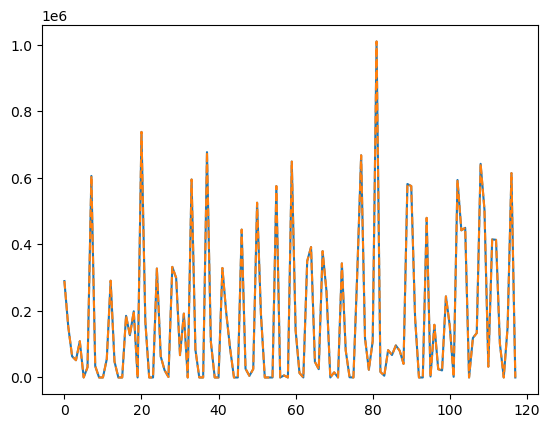

In [5]:
plot_dynamic_week_and_target(DYNAMIC_FEATURE_WEEK_PATH, TARGET_PATH, inn_id='inn1000409')

In [2]:
save_dataset_week(DATASET_WEEK_PATH, DYNAMIC_FEATURE_WEEK_PATH, STATIC_FEATURE_PATH, CAT_FEATURE_PATH)

2025-03-31,11:04:19 Load dynamic data /mnt/data/ods/example/../data/dynamic_feature_week.parquet
2025-03-31,11:04:26 Load static data /mnt/data/ods/example/../data/static_feature.parquet
2025-03-31,11:04:30 Get train dataset
2025-03-31,11:04:46 Get val dataset
2025-03-31,11:05:01 Get predict dataset


Saving the dataset (0/1 shards):   0%|          | 0/51963 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/51963 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/51963 [00:00<?, ? examples/s]

In [3]:
dataset = load_from_disk(str(DATASET_WEEK_PATH))
dataset

DatasetDict({
    train: Dataset({
        features: ['start', 'target', 'feat_dynamic_real', 'feat_static_real', 'feat_static_cat', 'inn_id'],
        num_rows: 51963
    })
    val: Dataset({
        features: ['start', 'target', 'feat_dynamic_real', 'feat_static_real', 'feat_static_cat', 'inn_id'],
        num_rows: 51963
    })
    predict: Dataset({
        features: ['start', 'target', 'feat_dynamic_real', 'feat_static_real', 'feat_static_cat', 'inn_id'],
        num_rows: 51963
    })
})

In [4]:
len(dataset['train'][0]['feat_static_real'])

450

In [5]:
len(dataset['train'][0]['target']), len(dataset['val'][0]['target']), len(dataset['predict'][0]['target']), 

(106, 118, 130)

<Axes: >

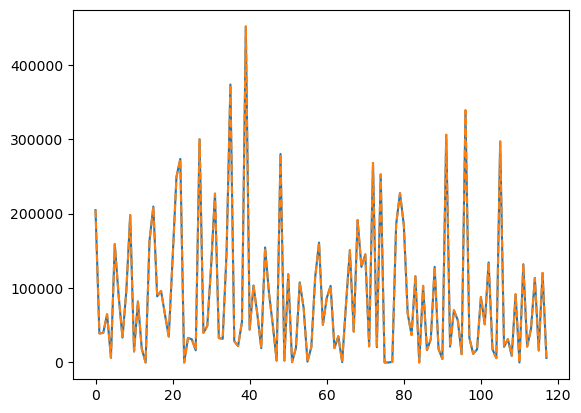

In [6]:
import numpy as np
target = pd.read_parquet(TARGET_PATH)
target = target[target.inn_id==dataset['val'][323]['inn_id']]
target.reset_index(drop=True, inplace=True)
target['target2'] = np.expm1(dataset['val'][323]['target'])
target['target2'].plot()
target['target'].plot(linestyle='dashed')
